In [ ]:
import os
import re
import sqlite3

import jsonlines
import pandas as pd
import polars as pl

In [2]:
data_path       = f'../data'
# tables_path     = f'{data_path}/datasets/CAN/tables/tables_from10000_to15000'
# metadata_path   = f'{data_path}/datasets/CAN/metadata/metadata_from10000_to15000'
tables_path     = f'{data_path}/datasets/CAN/tables/tables_from0_to10000'
metadata_path   = f'{data_path}/datasets/CAN/metadata/metadata_from0_to10000.jsonl'

evaluated_path  = f'{data_path}/outputs/evaluated_joins.csv'

In [3]:
table_ids = list(sorted(os.listdir(tables_path), reverse=True))

In [ ]:
evals = pd.read_csv(evaluated_path)
# evals.with_columns(
#     (pl.when(pl.col('ollama/qwen2.5:14b_score') == 'NO_SCORE').then(-1).otherwise(pl.col('ollama/qwen2.5:14b_score').cast(pl.Int8)).alias('ollama/qwen2.5:14b_score'))
# )
evals


,r_tab_id,s_tab_id,r_col_id,s_col_id,r_col_name,s_col_name,size_r_col,size_s_col,r_pkg_id,s_pkg_id,size_intersection,size_union,jaccard,overlap,ollama/qwen2.5:14b_score,ollama/qwen2.5:14b_explanation,ollama/qwen2.5:14b_errors,ollama/deepseek-r1:14b_score,ollama/deepseek-r1:14b_explanation,ollama/deepseek-r1:14b_errors
0,0,6567,1,1,FULL COLUMN NAME,Field / Champ,11,8,82cad281-ff7d-47b3-b2ce-9f794257e86d,53cc3681-6026-4fbb-af75-a225ac905caf,4,15,0.267,0.500,4,<score>4</score> The columns share common Arc...,NaN,-1,NO_EXPLANATION,Connection error.
1,0,1825,1,0,FULL COLUMN NAME,FIELD NAME / NOM DU CHAMP,11,9,82cad281-ff7d-47b3-b2ce-9f794257e86d,8ba7bced-b63f-462a-a8a1-7c7c8a7bcfa4,4,16,0.250,0.444,0,<score>0</score> The columns 'FULL COLUMN NAM...,NaN,0,<score>0</score> The columns 'FULL COLUMN NAM...,NaN
2,2,2233,1,2,Month,Months - Mois,12,12,53e61c06-cf86-40d5-90b6-86b62d48c281,0ddba181-11e2-4282-a718-99f3f5e8d9c5,12,12,1.000,1.000,2,<score>2</score> The columns 'Month' from the...,NaN,2,<score>2</score> The columns 'Month' from the...,NaN
3,2,1364,1,2,Month,Survey-month_Mois-du-sondage-ENG,12,12,53e61c06-cf86-40d5-90b6-86b62d48c281,4a251d2f-3ed5-4b5f-a57b-b841b11177bf,12,12,1.000,1.000,4,<score>4</score> Explanation: The data shows ...,NaN,4,<score>4</score> Explanation: The data shows ...,NaN
4,3,5186,3,7,Vegetation Plot Number,VECTOR,12,15,f236214e-4d1b-40c6-8ecc-d62664f5c2b0,ec690886-687d-4d59-9b1b-51311435d344,6,21,0.286,0.500,4,<score>4</score> Explanation: The two dataset...,NaN,4,<score>4</score> Explanation: The two dataset...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,36,6131,6,7,Nom_RE,Economic Region Name,82,86,adad580f-76b0-4502-bd05-20c125de9116,b0e112e9-cf53-4e79-8838-23cd98debe5b,30,138,0.217,0.366,4,<score>4</score> Explanation: The data provid...,NaN,4,<score>4</score> Explanation: The data provid...,NaN
96,36,5378,6,7,Nom_RE,Economic Region Name,82,84,adad580f-76b0-4502-bd05-20c125de9116,b0e112e9-cf53-4e79-8838-23cd98debe5b,30,136,0.221,0.366,4,<score>4</score> Explanation: The data provid...,NaN,4,<score>4</score> Explanation: The data provid...,NaN
97,36,6917,6,7,Nom_RE,Economic Region Name,82,84,adad580f-76b0-4502-bd05-20c125de9116,b0e112e9-cf53-4e79-8838-23cd98debe5b,30,136,0.221,0.366,4,<score>4</score> Explanation: The data provid...,NaN,4,<score>4</score> Explanation: The data provid...,NaN
98,36,6382,6,7,Nom_RE,Economic Region Name,82,84,adad580f-76b0-4502-bd05-20c125de9116,b0e112e9-cf53-4e79-8838-23cd98debe5b,30,136,0.221,0.366,4,<score>4</score> Explanation: The data provid...,NaN,4,<score>4</score> Explanation: The data provid...,NaN


In [5]:
evals.describe()

,r_tab_id,s_tab_id,r_col_id,s_col_id,size_r_col,size_s_col,size_intersection,size_union,jaccard,overlap,ollama/qwen2.5:14b_score,ollama/deepseek-r1:14b_score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,23.460000,4047.110000,3.960000,5.050000,362.230000,545.080000,280.100000,627.210000,0.575170,0.850880,2.840000,2.780000
std,11.866616,2501.790179,3.087675,4.736224,1346.287007,2822.420029,884.277866,3029.087729,0.301247,0.212892,1.829721,1.867208
min,0.000000,20.000000,0.000000,0.000000,8.000000,7.000000,3.000000,11.000000,0.202000,0.353000,-1.000000,-1.000000
25%,14.000000,1690.000000,1.000000,1.000000,21.000000,42.750000,15.500000,48.500000,0.271250,0.814000,2.000000,2.000000
50%,24.000000,3887.500000,3.000000,5.000000,82.000000,86.000000,39.000000,128.000000,0.593000,0.968000,4.000000,4.000000
75%,36.000000,6382.000000,7.000000,7.000000,516.000000,498.000000,407.000000,534.250000,0.939000,0.996000,4.000000,4.000000
max,37.000000,8558.000000,9.000000,30.000000,11341.000000,27732.000000,7531.000000,27735.000000,1.000000,1.000000,4.000000,4.000000


<Axes: >

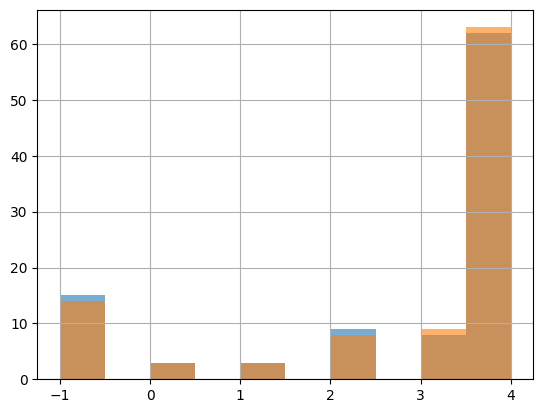

In [6]:
evals['ollama/deepseek-r1:14b_score'].hist(alpha=0.6)
evals['ollama/qwen2.5:14b_score'].hist(alpha=0.6)

In [7]:
pl.read_parquet(f'{tables_path}/{table_ids[36]}').head()

ï»¿NOC_CNP,NOC_TITLE_ENG,NOC_TITLE_FRA,prov,ER_Code_Code_RE,ER_Name,Nom_RE,Low_Wage_Salaire_Minium,Median_Wage_Salaire_Median,High_Wage_Salaire_Maximal,Average_Wage_Salaire_Moyen,Data_Source_E,Data_Source_F,Reference_Period,Revision_Date_Date_revision,Annual_Wage_Flag_Salaire_annuel,Wage_Comment_E,Wage_Comment_F
str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,i64,str,str
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""",null,"""ER00""","""Canada""","""Canada""",31600.0,84000.0,184000.0,97600.0,"""2021 Census""","""Recensement 2021""","""2021""","""2023-11-29""",1,"""Wages for this occupation are …","""Pour cette profession sont prÃ…"
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER10""","""Newfoundland and Labrador""","""Terre-Neuve-et-Labrador""",null,99000.0,null,90000.0,"""2021 Census""","""Recensement 2021""","""2021""","""2023-11-29""",1,"""Wages for this occupation are …","""Pour cette profession sont prÃ…"
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER1010""","""Avalon Peninsula""","""Avalon Peninsula""",null,null,null,null,null,null,null,"""2023-11-29""",0,null,null
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER1020""","""South Coast--Burin Peninsula""","""CÃ´te-sud--Burin Peninsula""",null,null,null,null,null,null,null,"""2023-11-29""",0,null,null
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER1030""","""West Coast--Northern Peninsula…","""CÃ´te-ouest--Northern Peninsul…",null,null,null,null,null,null,null,"""2023-11-29""",0,null,null


In [8]:
pl.read_parquet(f'{tables_path}/{table_ids[6491]}').head()

Code,Occupation_Name,Nom_de_la_profession,Future_Labour_Market_Conditions,Conditions_futures_sur_le_marché_du_travail
str,str,str,str,str
"""00000""","""All Occupations""","""Toutes les professions""",null,"""N/D"""
"""TEER_0""","""TEER 0: Management occupations""","""FÉER 0: Professions en gestion""",null,"""N/D"""
"""TEER_1""","""TEER 1: Occupations usually re…","""FÉER 1: Une formation universi…",null,"""N/D"""
"""TEER_2""","""TEER 2: Occupations usually re…","""FÉER 2: Un diplôme détudes co…",null,"""N/D"""
"""TEER_3""","""TEER 3: Occupations usually re…","""FÉER 3: Un diplôme détudes co…",null,"""N/D"""


# Agent Question Generation

In [14]:
from typing import List
from typing_extensions import Annotated 

from autogen_agentchat.agents import AssistantAgent
from autogen_core.models import ModelFamily
from autogen_agentchat.messages import TextMessage
from autogen_core import CancellationToken
from autogen_core.tools import FunctionTool, Tool
from autogen_ext.models.ollama import OllamaChatCompletionClient
from autogen_ext.models.openai import OpenAIChatCompletionClient

In [10]:
async def create_agent(
        model: str = "ollama/llama3.3",
        base_url: str = "http://localhost:4000",
        api_key: str = "NotRequiredSinceWeAreLocal",
        temperature: int = 0,
        system_message: str = "You are a smart AI assistant.",        
        model_info: dict = {
            "json_output"       : False,
            "vision"            : False,
            "function_calling"  : True,
            "family"            : ModelFamily.UNKNOWN,
            "keep_alive"        : "6h", # to keep the model in memory more time
            "num_ctx"           : 8192 # to increase the context size (not sure) 
        }, tools: List[Tool] = []) -> AssistantAgent:
    
    # model_client = OllamaChatCompletionClient(
    model_client = OpenAIChatCompletionClient(
        model=model,
        temperature=temperature,
        api_key=api_key,
        base_url=base_url,
        model_info=model_info
    )

    # create the assistant agent
    agent = AssistantAgent(
        name="NaturalLanguageGeneratorAssistant",
        model_client=model_client,
        system_message=system_message
    )
    
    return agent

In [ ]:
results = []

async def eval_and_save_question(r_table_id: Annotated[str, "The left table ID as passed by the user."], 
                                 s_table_id: Annotated[str, "The right table ID as passed by the user."],
                                 r_column_id: Annotated[str, "The left column ID where the join is performed"],
                                 s_column_id: Annotated[str, "The right column ID where the join is performed"],
                                 natural_language_question: Annotated[str, "A natural language question which involves the two tables and the columns specified by the user."], 
                                 sql_query: Annotated[str, "A SQL query which represents the natural language question."]):
    con, cur, result, error = None, None, None, None
    try:
        con = sqlite3.connect("tables.db")
        cur = con.cursor()
        cur.execute(sql_query)
        
        result = cur.fetchmany()
    except sqlite3.Error as e:
        error = str(e)
    finally:
        if con: con.close()

    if error:
        return {
            "error": error,
            "wrong_result": result if result else "N/A"            
        }
    elif len(result) == 0:
        return {
            "error": "Empty result set",
        }
    else:
        results.append([r_table_id, s_table_id, natural_language_question, sql_query])
        return {"result": result}

In [18]:
nl_gen_system_message = """
    You are a smart AI assistant. 
    Your task is to generate natural language questions from tables that
    joins toghether and the relative SQL queries.
    You have to return a clear and short question about the tables and the join.
    Use the provided tools.
"""

nl_gen_agent = await create_agent(
    model="ollama/deepseek-r1:14b",
    system_message=nl_gen_system_message
)

In [24]:
row = evals.sample()
row

,r_tab_id,s_tab_id,r_col_id,s_col_id,r_col_name,s_col_name,size_r_col,size_s_col,r_pkg_id,s_pkg_id,size_intersection,size_union,jaccard,overlap,ollama/qwen2.5:14b_score,ollama/qwen2.5:14b_explanation,ollama/qwen2.5:14b_errors,ollama/deepseek-r1:14b_score,ollama/deepseek-r1:14b_explanation,ollama/deepseek-r1:14b_errors
83,36,3438,3,9,prov,Province,14,36,adad580f-76b0-4502-bd05-20c125de9116,8940f53e-74e5-486c-b5ed-458a935d98aa,13,37,0.351,0.929,4,<score>4</score> Explanation: The two dataset...,NaN,4,<score>4</score> Explanation: The two dataset...,NaN


In [29]:
r_df = pl.read_parquet(f"{tables_path}/{table_ids[36]}")
r_df.head()

ï»¿NOC_CNP,NOC_TITLE_ENG,NOC_TITLE_FRA,prov,ER_Code_Code_RE,ER_Name,Nom_RE,Low_Wage_Salaire_Minium,Median_Wage_Salaire_Median,High_Wage_Salaire_Maximal,Average_Wage_Salaire_Moyen,Data_Source_E,Data_Source_F,Reference_Period,Revision_Date_Date_revision,Annual_Wage_Flag_Salaire_annuel,Wage_Comment_E,Wage_Comment_F
str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,i64,str,str
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""",null,"""ER00""","""Canada""","""Canada""",31600.0,84000.0,184000.0,97600.0,"""2021 Census""","""Recensement 2021""","""2021""","""2023-11-29""",1,"""Wages for this occupation are …","""Pour cette profession sont prÃ…"
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER10""","""Newfoundland and Labrador""","""Terre-Neuve-et-Labrador""",null,99000.0,null,90000.0,"""2021 Census""","""Recensement 2021""","""2021""","""2023-11-29""",1,"""Wages for this occupation are …","""Pour cette profession sont prÃ…"
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER1010""","""Avalon Peninsula""","""Avalon Peninsula""",null,null,null,null,null,null,null,"""2023-11-29""",0,null,null
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER1020""","""South Coast--Burin Peninsula""","""CÃ´te-sud--Burin Peninsula""",null,null,null,null,null,null,null,"""2023-11-29""",0,null,null
"""NOC_00010""","""Legislators""","""Membres des corps lÃ©gislatifs""","""NL""","""ER1030""","""West Coast--Northern Peninsula…","""CÃ´te-ouest--Northern Peninsul…",null,null,null,null,null,null,null,"""2023-11-29""",0,null,null


In [34]:
r_tab_id, s_tab_id, r_col_id, s_col_id, r_col_name, s_col_name = row.row(0)[:6]

AttributeError: 'DataFrame' object has no attribute 'row'

In [ ]:
con = sqlite.connection("tables.db")
r_df.write_database(

In [ ]:
row.

,r_tab_id,s_tab_id,r_col_id,s_col_id,r_col_name,s_col_name,size_r_col,size_s_col,r_pkg_id,s_pkg_id,size_intersection,size_union,jaccard,overlap,ollama/qwen2.5:14b_score,ollama/qwen2.5:14b_explanation,ollama/qwen2.5:14b_errors,ollama/deepseek-r1:14b_score,ollama/deepseek-r1:14b_explanation,ollama/deepseek-r1:14b_errors
83,36,3438,3,9,prov,Province,14,36,adad580f-76b0-4502-bd05-20c125de9116,8940f53e-74e5-486c-b5ed-458a935d98aa,13,37,0.351,0.929,4,<score>4</score> Explanation: The two dataset...,NaN,4,<score>4</score> Explanation: The two dataset...,NaN
